# Plumbing Failure Prediction Model

Binary classification to predict plumbing failure in the next 30 days.

- Target: `failure_within_30_days` (0/1)
- Primary model: RandomForestClassifier
- Baseline: LogisticRegression

Run `Preprocessing-Pipeline.ipynb` first.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, joblib, json, warnings

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix, roc_auc_score, roc_curve)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

## 1. Load Data

In [2]:
df = pd.read_csv('../data/preprocessed/plumbing_data.csv')
print(f'Plumbing data: {df.shape}')
print(f'Target balance: {df["failure_within_30_days"].mean():.2%} positive')
df['failure_within_30_days'].value_counts()

Plumbing data: (16712, 48)
Target balance: 39.06% positive


failure_within_30_days
0    10184
1     6528
Name: count, dtype: int64

## 2. Feature Selection

In [3]:
plumbing_features = [
    'water_leak', 'toilet_functional_ratio', 'roof_leak_flag',
    'condition_score', 'students_per_toilet', 'num_students',
    'weeks_since_last_repair', 'days_since_repair', 'repair_done',
    'condition_trend', 'deterioration_rate', 'urgency_score',
    'crack_width_mm', 'building_age', 'girls_school', 'flood_prone_area',
]

# add one-hot encoded columns
weather_cols = [c for c in df.columns if c.startswith('weather_zone_')]
material_cols = [c for c in df.columns if c.startswith('material_type_')]
plumbing_features.extend(weather_cols)
plumbing_features.extend(material_cols)

# keep only columns that exist
plumbing_features = [f for f in plumbing_features if f in df.columns]

TARGET = 'failure_within_30_days'
X = df[plumbing_features].fillna(0)
y = df[TARGET]

print(f'Features: {len(plumbing_features)}')
print(f'X: {X.shape}, y: {y.shape}')

Features: 24
X: (16712, 24), y: (16712,)


## 3. Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

Train: 13369, Test: 3343


## 4. Baseline — Logistic Regression

In [5]:
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print('Logistic Regression Results:')
print(f'  Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'  F1:        {f1_score(y_test, y_pred_lr):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred_lr):.4f}')
print(f'  Recall:    {recall_score(y_test, y_pred_lr):.4f}')
print(f'  ROC AUC:   {roc_auc_score(y_test, y_prob_lr):.4f}')

Logistic Regression Results:
  Accuracy:  0.9922
  F1:        0.9901
  Precision: 0.9805
  Recall:    1.0000
  ROC AUC:   1.0000


## 5. Primary Model — Random Forest

In [6]:
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_split=5,
    min_samples_leaf=2, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print('Random Forest Results:')
print(f'  Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'  F1:        {f1_score(y_test, y_pred_rf):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred_rf):.4f}')
print(f'  Recall:    {recall_score(y_test, y_pred_rf):.4f}')
print(f'  ROC AUC:   {roc_auc_score(y_test, y_prob_rf):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['No Failure','Failure']))

Random Forest Results:
  Accuracy:  1.0000
  F1:        1.0000
  Precision: 1.0000
  Recall:    1.0000
  ROC AUC:   1.0000

Classification Report:
              precision    recall  f1-score   support

  No Failure       1.00      1.00      1.00      2037
     Failure       1.00      1.00      1.00      1306

    accuracy                           1.00      3343
   macro avg       1.00      1.00      1.00      3343
weighted avg       1.00      1.00      1.00      3343



In [7]:
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='f1')
print(f'5-Fold CV F1: {cv_scores.round(4)}')
print(f'Mean: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

5-Fold CV F1: [0.9996 1.     1.     0.9996 1.    ]
Mean: 0.9998 +/- 0.0002


## 6. Evaluation Plots

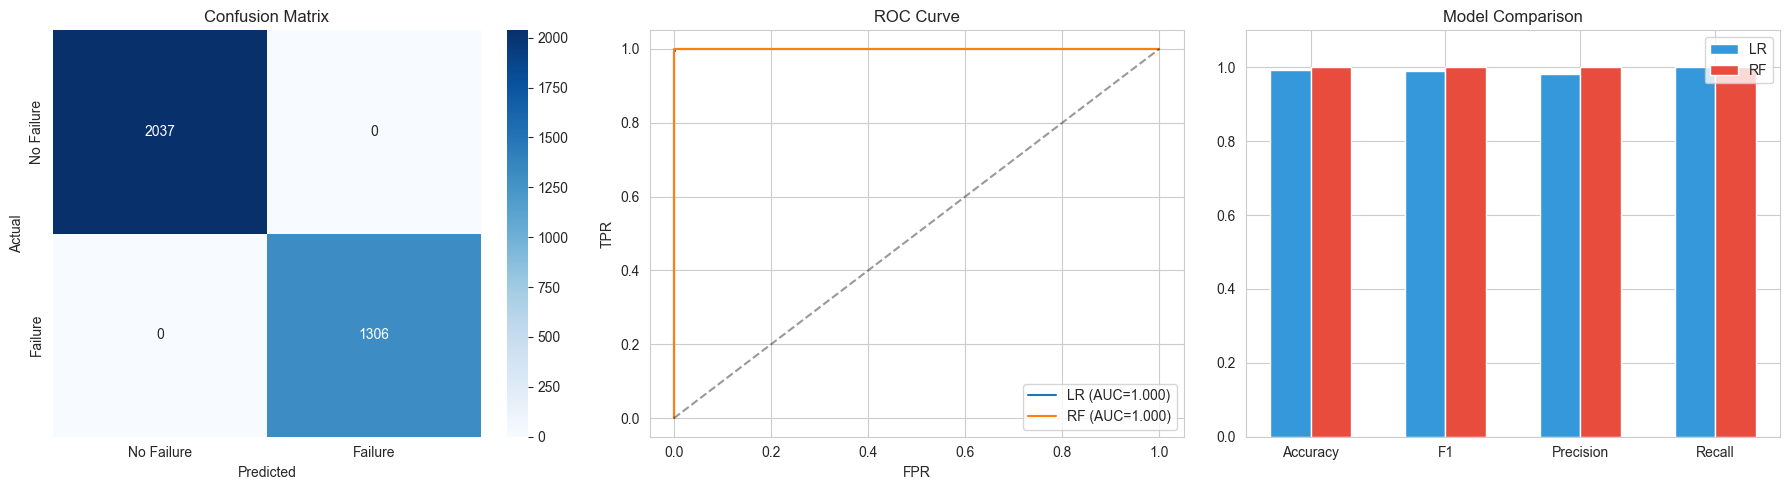

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Failure','Failure'], yticklabels=['No Failure','Failure'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# roc curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
axes[1].plot(fpr_lr, tpr_lr, label=f'LR (AUC={roc_auc_score(y_test, y_prob_lr):.3f})')
axes[1].plot(fpr_rf, tpr_rf, label=f'RF (AUC={roc_auc_score(y_test, y_prob_rf):.3f})')
axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()

# metric comparison
metrics = ['Accuracy','F1','Precision','Recall']
lr_vals = [accuracy_score(y_test,y_pred_lr), f1_score(y_test,y_pred_lr),
           precision_score(y_test,y_pred_lr), recall_score(y_test,y_pred_lr)]
rf_vals = [accuracy_score(y_test,y_pred_rf), f1_score(y_test,y_pred_rf),
           precision_score(y_test,y_pred_rf), recall_score(y_test,y_pred_rf)]
x = np.arange(len(metrics))
axes[2].bar(x-0.15, lr_vals, 0.3, label='LR', color='#3498db')
axes[2].bar(x+0.15, rf_vals, 0.3, label='RF', color='#e74c3c')
axes[2].set_xticks(x)
axes[2].set_xticklabels(metrics)
axes[2].set_ylim(0,1.1)
axes[2].set_title('Model Comparison')
axes[2].legend()

plt.tight_layout()
plt.show()

## 7. Feature Importance and Explainability

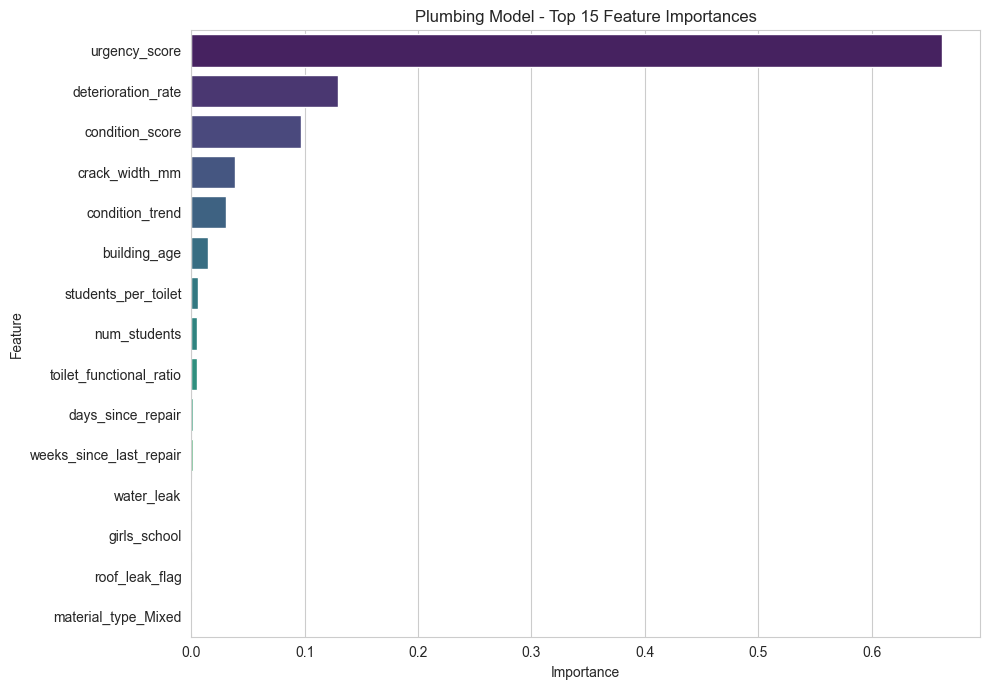

Top 10 features:
  urgency_score                  0.6626
  deterioration_rate             0.1295
  condition_score                0.0964
  crack_width_mm                 0.0387
  condition_trend                0.0308
  building_age                   0.0149
  students_per_toilet            0.0057
  num_students                   0.0053
  toilet_functional_ratio        0.0049
  days_since_repair              0.0017


In [9]:
feat_imp = pd.DataFrame({
    'Feature': plumbing_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=feat_imp.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Plumbing Model - Top 15 Feature Importances')
plt.tight_layout()
plt.show()

print('Top 10 features:')
for _, row in feat_imp.head(10).iterrows():
    print(f"  {row['Feature']:30s} {row['Importance']:.4f}")

In [10]:
def explain_plumbing(model, features, feature_names, top_n=5):
    """Returns prediction with human-readable explanation."""
    features_arr = np.array(features).reshape(1, -1)
    pred = model.predict(features_arr)[0]
    prob = model.predict_proba(features_arr)[0]
    fail_prob = prob[1]

    risk = 'High' if fail_prob >= 0.7 else ('Medium' if fail_prob >= 0.4 else 'Low')

    # top contributing features
    imp = model.feature_importances_
    top = sorted(zip(feature_names, features, imp), key=lambda x: x[2], reverse=True)[:top_n]

    labels = {
        'water_leak': 'water leakage detected',
        'toilet_functional_ratio': 'low toilet functionality',
        'students_per_toilet': 'high student-to-toilet ratio',
        'weeks_since_last_repair': 'long time since repair',
        'condition_trend': 'declining condition trend',
        'building_age': 'old building',
        'urgency_score': 'high urgency',
        'deterioration_rate': 'rapid deterioration',
    }
    reasons = [labels.get(f[0], f[0]) for f in top[:3]]

    return {
        'prediction': int(pred),
        'failure_probability': round(float(fail_prob), 4),
        'risk_level': risk,
        'top_features': [{'name': f[0], 'importance': round(float(f[2]), 4)} for f in top],
        'explanation': f"{risk} plumbing risk due to: {', '.join(reasons)}."
    }

# test it
sample = X_test.iloc[0].values
result = explain_plumbing(rf_model, sample, plumbing_features)
print('Example prediction:')
print(json.dumps(result, indent=2))

Example prediction:
{
  "prediction": 1,
  "failure_probability": 0.9343,
  "risk_level": "High",
  "top_features": [
    {
      "name": "urgency_score",
      "importance": 0.6626
    },
    {
      "name": "deterioration_rate",
      "importance": 0.1295
    },
    {
      "name": "condition_score",
      "importance": 0.0964
    },
    {
      "name": "crack_width_mm",
      "importance": 0.0387
    },
    {
      "name": "condition_trend",
      "importance": 0.0308
    }
  ],
  "explanation": "High plumbing risk due to: high urgency, rapid deterioration, condition_score."
}


## 8. Save Model

In [11]:
os.makedirs('../models', exist_ok=True)

joblib.dump(rf_model, '../models/plumbing_model.pkl')
joblib.dump(lr_model, '../models/plumbing_baseline_lr.pkl')
joblib.dump(plumbing_features, '../models/plumbing_features.pkl')

metrics_dict = {
    'model': 'RandomForestClassifier',
    'category': 'plumbing',
    'target': TARGET,
    'n_features': len(plumbing_features),
    'accuracy': round(float(accuracy_score(y_test, y_pred_rf)), 4),
    'f1_score': round(float(f1_score(y_test, y_pred_rf)), 4),
    'precision': round(float(precision_score(y_test, y_pred_rf)), 4),
    'recall': round(float(recall_score(y_test, y_pred_rf)), 4),
    'roc_auc': round(float(roc_auc_score(y_test, y_prob_rf)), 4),
    'cv_mean_f1': round(float(cv_scores.mean()), 4),
    'features': plumbing_features
}
with open('../models/plumbing_metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=2)

print('Plumbing model saved to models/')
print(f'  Accuracy: {metrics_dict["accuracy"]}')
print(f'  F1:       {metrics_dict["f1_score"]}')
print(f'  ROC AUC:  {metrics_dict["roc_auc"]}')

Plumbing model saved to models/
  Accuracy: 1.0
  F1:       1.0
  ROC AUC:  1.0
